In [ ]:
import os, sys, json
sys.path.append('../../../')
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)
tokenizer.bypass_inference=True

lung_dataset = "/media/lleger/LaCie/mit/disease_geometry/cxg_lung_dataset/"
os.listdir(lung_dataset)
import numpy as np, pandas as pd, scanpy as sc

cells = sc.concat([sc.read_h5ad(lung_dataset + file) for file in os.listdir(lung_dataset)])
print('loaded', cells.shape)

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell

embeddings = np.load('../information_geometry/polygene_cxg_lung_embeddings.npy')
lung_cancers = ["lung adenocarcinoma", "lung large cell carcinoma", "squamous cell lung carcinoma", "small cell lung carcinoma", "normal"]

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading checkpoint-1500000
loaded (74832, 60664)


In [33]:
import sys
sys.path.append('../../../')
from tqdm import tqdm
from sklearn.decomposition import PCA
from torch.nn.functional import softmax
import os, sys, torch, numpy as np, pandas as pd
from polygene.data_utils.tokenization import normalise_str

lung_cancers = ["lung adenocarcinoma", "lung large cell carcinoma", "squamous cell lung carcinoma", "small cell lung carcinoma", "normal"]
disease_representations = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[[tokenizer.token_to_id_map[normalise_str(disease)] for disease in lung_cancers]]

decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature
W = model.prediction_head[-1].weight
tau = model.temperature

regularizing_temperature = 4
# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
from torch.nn.functional import softmax
@torch.no_grad()
def riemannian_metric(z, W, tau, temperature=2):
    p = softmax((W @ z) / tau / temperature, dim=0)
    w_tau = (W / tau)
    fisher_information_metric = torch.diag(p) - torch.outer(p, p)
    return w_tau.T @ fisher_information_metric @ w_tau

@torch.no_grad()
def amari_chentsov_tensor(z, W, tau, temperature=2):# skewness tensor
    probability_distribution = torch.softmax((W @ z) / tau, dim=0)# / temperature, dim=0)
    fisher_information_matrix = riemannian_metric(z, W, tau,)# regularization)#=1e-4)
    
    mean = (W / tau ).T @ probability_distribution
    jacobian = W / tau #/ temperature
    start= time.time()
    third_moment = torch.einsum('i,ia,ib,ic->abc', probability_distribution, jacobian, jacobian, jacobian)
    mean_covariance = torch.einsum('ab,c->abc', fisher_information_matrix, mean) + torch.einsum('ac,b->abc', fisher_information_matrix, mean) + torch.einsum('bc,a->abc', fisher_information_matrix, mean)    
    cubic_mean = torch.einsum('a,b,c->abc', mean, mean, mean)

    return third_moment - mean_covariance - cubic_mean

@torch.no_grad()
def amari_chentsov_tensor_2(z, W, tau, temperature = 2):
    p = torch.softmax((W @ z) / tau , dim=0)#/ temperature, dim=0)
    J = W / tau #/ temperature
    mean = J.T @ p
    centered = J - mean
    C = torch.einsum('i,ia,ib,ic->abc', p, centered, centered, centered)
    return C

import time
@torch.no_grad()
def amari_chentsov_tensor(z, W, tau, temperature = 2):
    p = torch.softmax((W @ z) / tau / temperature, dim=0) 
    w_tau = (W / tau)

    # putting large dimensions fist, vocabulary size is larger than d
    first_order_tensor = torch.einsum("m, mi, mj, mk -> ijk", p, w_tau, w_tau, w_tau)

    second_order_tensors = - torch.einsum("m, mi, mj, l, lk -> ijk", p, w_tau, w_tau, p, w_tau)\
                        - torch.einsum("m, mi, mk, l, lj-> ijk", p , w_tau, w_tau, p, w_tau)\
                        - torch.einsum("m, mi, l, lj, lk -> ijk", p, w_tau, p, w_tau, w_tau)  
    
    third_order_tensor = 2*torch.einsum("m, mi, l, lj, n, nk -> ijk", p, w_tau, p, w_tau, p, w_tau)

    return first_order_tensor + second_order_tensors + third_order_tensor

@torch.no_grad()
def levi_civita_connection(z, W, tau, temperature):
    G = riemannian_metric(z, W, tau, temperature)
    dG = amari_chentsov_tensor(z, W, tau, temperature)
    raised_G = torch.inverse(G)
    return torch.einsum('kc,abc->abk', raised_G, 0.5 * dG)


import numpy as np

gradients_per_grid_side, border, whiten_pca = 10, 1, True

df = pd.DataFrame({"embeddings": embeddings.tolist(), "disease": cells.obs['disease']})
pca = PCA(n_components=2, whiten=whiten_pca, svd_solver="full", random_state=3)

df[['x','y']] = pca.fit_transform(np.array(df['embeddings'].tolist())).tolist()
explained_var = pca.explained_variance_ratio_

# sample a grid of points in the linear slice of the manifold
x_min, x_max = df['x'].min()-border, df['x'].max()+border
y_min, y_max = df['y'].min()-border, df['y'].max()+border
grid_x, grid_y = np.linspace(x_min, x_max, gradients_per_grid_side), np.linspace(y_min, y_max, gradients_per_grid_side)
X, Y = np.meshgrid(grid_x, grid_y)

grid_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
grid_embeddings = pca.inverse_transform(grid_coordinates)

vector_fields = {"meshgrid_coordinates": (X, Y)}
for z in tqdm(grid_embeddings):
    z = torch.tensor(z / np.linalg.norm(z, axis=-1), device=model.device, dtype=torch.float32, requires_grad=True)
    metric = riemannian_metric(z, W, tau)#
    inverse_metric = torch.linalg.inv(metric).detach().cpu().numpy()
    probability_distribution = softmax(decoder(z), dim=0)
    probability_of_disease  = probability_distribution[tokenizer.token_to_id_map[normalise_str(disease)]]
    probability_of_disease.backward(retain_graph=True)
    gradient = z.grad.detach().cpu().numpy()
    vector_fields.setdefault(f"{disease}_gradients", []).append(gradient)
    vector_fields.setdefault(f"{disease}_riemannian", []).append( gradient @ inverse_metric)
    
    eigvals = np.linalg.eigvalsh(metric.detach().cpu().numpy())
    log_volume = .5 * np.sum(np.log(1 + eigvals))
    volume = np.log(1+np.sqrt(np.product(eigvals)))
    spectral_probability = eigvals / np.sum(eigvals)
    spectral_entropy = -np.sum(spectral_probability * np.log(spectral_probability + 1e-12))
    condition_number = eigvals[-1] / eigvals[0]
    eff_rank = np.exp(spectral_entropy)
    cumulative_eigenvalues = np.cumsum(eigvals[::-1])
    intrinsic_dimensionality = np.where(cumulative_eigenvalues / cumulative_eigenvalues[-1] > 0.99)[0].min()
    vector_fields.setdefault(f"spectral", []).append( spectral_entropy)
    vector_fields.setdefault(f"log_volume", []).append( log_volume )
    vector_fields.setdefault(f"condition", []).append( condition_number)
    vector_fields.setdefault(f"rank", []).append( eff_rank)
    vector_fields.setdefault(f"dim", []).append( intrinsic_dimensionality)
    temp = 2
    vector_fields.setdefault(f"amari", []).append(amari_chentsov_tensor(z, W, tau, temperature=temp).norm().item())
    vector_fields.setdefault(f"levi", []).append(levi_civita_connection(z, W, tau, temperature=temp).norm().item())
    z.grad.zero_()


from scipy.linalg import orthogonal_procrustes
for key in vector_fields:
    if not disease in key: continue
    #gradients = np.array(vector_fields[key])
    #gradient_pca = PCA(2, whiten=True, svd_solver="full").fit(gradients)
    #R, _ = orthogonal_procrustes(gradient_pca.components_.T, pca.components_.T)
    #vector_fields[key] = gradient_pca.transform(gradients) @ R
    
    #vector_fields[key] = pca.fit_transform(np.array(vector_fields[key]))
    vector_fields[key] = np.array(vector_fields[key]) @ pca.components_.T

  6%|▌         | 6/100 [00:00<00:03, 27.37it/s]/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 100/100 [00:03<00:00, 29.00it/s]


/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewdiths'
  cset = contour_func(


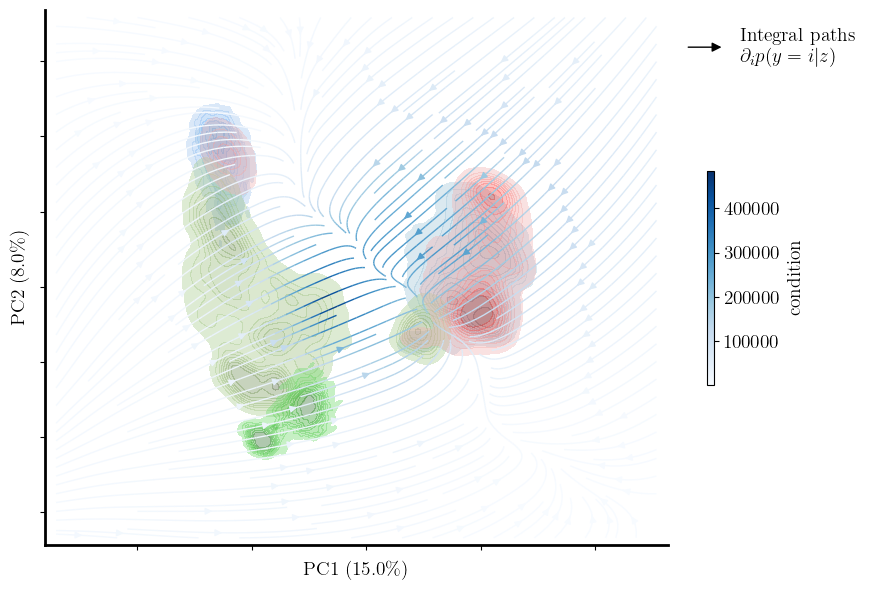

In [34]:
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
import matplotlib.pyplot as plt, seaborn as sns

arrow_scale, arrow_width, arrow_color = 5, 0.004, "k"

disease_representations_pca = pca.transform(disease_representations)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fontsize, dpi=14, 100
plot_border = 1.1*border
X, Y = vector_fields['meshgrid_coordinates']
gradients = vector_fields[f'{disease}_riemannian'].reshape(X.shape[0], X.shape[1], -1)
gradients = vector_fields[f'{disease}_gradients'].reshape(X.shape[0], X.shape[1], -1)

#for geometric_statistic in ["condition", "volume", "rank", "spectral", "amari", "dim"]:
#for geometric_statistic in ["levi", "volume", "rank", "spectral", "amari", "dim"]:
#for geometric_statistic in ["amari", "amari_2", "levi", "levi_2"]:
#for geometric_statistic in ["amari", "amari_2", "amari_3", "levi", "levi_2", "levi_3"]:

for gdx, geometric_statistic in enumerate(["condition", "log_volume", "rank", "dim", "spectral", "amari",  "levi",]):
    statistic = np.array(vector_fields[geometric_statistic]).reshape(X.shape[0], X.shape[1])
    fig, ax = plt.subplots(1,1, figsize=(9, 6), dpi=dpi)

    width = 2*np.log(1 + np.linalg.norm(gradients, axis=-1)) / np.log(1 + np.linalg.norm(gradients, axis=-1)).max()

    gradients_normalised = gradients / np.linalg.norm(gradients, axis=-1, keepdims=True)

    stream = ax.streamplot(X, Y, gradients_normalised[:, :, 0],gradients_normalised[:, :, 1], broken_streamlines=True,
                    integration_direction="both", density=2, 
                    #color=(0, 0, 0, 1),
                    color=statistic,
                    cmap="Blues",
                    # linewidth=width,
                    linewidth=1,
                    )
    bar = fig.colorbar(stream.lines, shrink=0.4, aspect=30, )
    bar.set_label(geometric_statistic, fontsize=fontsize)
    bar.ax.tick_params(labelsize=fontsize)
    ax.set_xticklabels([]);ax.set_yticklabels([])
    ax.spines[['top','right']].set_linewidth(0);ax.spines[['bottom','left']].set_linewidth(2)
    ax.set_xlim(df['x'].min()-plot_border,df['x'].max()+plot_border);ax.set_ylim(df['y'].min()-plot_border,df['y'].max()+plot_border)
    ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}\%)',fontsize=fontsize);ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}\%)',fontsize=fontsize)
    
    palette = sns.color_palette('Paired',n_colors=len(df['disease'].values.unique()))
    #sns.scatterplot(data=df,x='x',y='y',hue=df['disease'],palette=palette,s=10,alpha=0.8,ax=ax,linewidth=0,zorder=1)
    sns.kdeplot(data=df,x="x",y="y",hue="disease",palette=palette,fill=True,alpha=0.4,
                linewdiths=1, levels=10, 
                bw_adjust=0.5,ax=ax,zorder=1)
    arrow_gray = FancyArrowPatch((0,0),(1,0),arrowstyle='-|>',mutation_scale=15,color=arrow_color,linewidth=1)
    def make_handle(legend,orig_handle,xdescent,ydescent,width,height,fontsize):
        return FancyArrowPatch((0,height*0.5),(width,height*0.5),arrowstyle='-|>', mutation_scale=fontsize,color=orig_handle.get_edgecolor()
                                    if hasattr(orig_handle,'get_edgecolor') else orig_handle.get_facecolor(),linewidth=1)

    handles, legend_labels_= ax.get_legend_handles_labels()
    handles.append(arrow_gray)
    legend_labels_.append(f"Integral paths \n$\partial_i p (y = i | z)$")
    legend = ax.legend(handles, [label.replace('lung ', '').replace(' carcinoma', '').replace('normal', 'Normal Pneumocytes').title() if not "path" in label else label for label in legend_labels_], frameon=True,
                    bbox_to_anchor=(1,1),
                    #borderaxespad=0.5,
                      edgecolor='none',
                    fontsize=fontsize, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_handle)})
    for h in legend.legendHandles: 
        if hasattr(h,"set_markersize"): h.set_markersize(5); h.set_alpha(1)
    plt.tight_layout()
    #break
    plt.show()
    break

            